# Autovalores e autovetores

**Tema:** Álgebra Linear e Otimização › Decomposições: SVD, Autovalores e PCA

Uma matriz quadrada $A$ transforma vetores esticando, girando e refletindo. A
pergunta deste notebook: **existe alguma direção que $A$ não gira — só
estica?** A resposta é sim, quase sempre, e essas direções especiais
(autovetores) e seus fatores de esticamento (autovalores) explicam quase tudo
que $A$ faz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Uma matriz e sua "bússola invariante"

Vamos olhar para uma matriz simples e ver o que ela faz com um círculo de
vetores unitários — depois procurar as direções que não giram.

In [2]:
A = np.array([[2.0, 0.8],
              [0.4, 1.3]])

autovalores, autovetores = np.linalg.eig(A)
print("autovalores:", autovalores)
print("autovetores (uma coluna por autovetor):\n", autovetores)

# verificação direta da definição: A @ v == lambda * v
for i in range(2):
    v = autovetores[:, i]
    lam = autovalores[i]
    print(f"\nautovetor {i + 1}: v = {v}")
    print(f"  A @ v       = {A @ v}")
    print(f"  lambda * v  = {lam * v}")

autovalores: [2.3152+0.j 0.9848+0.j]
autovetores (uma coluna por autovetor):
 [[ 0.9304+0.j -0.6189+0.j]
 [ 0.3666+0.j  0.7854+0.j]]

autovetor 1: v = [0.9304+0.j 0.3666+0.j]
  A @ v       = [2.154 +0.j 0.8487+0.j]
  lambda * v  = [2.154 +0.j 0.8487+0.j]

autovetor 2: v = [-0.6189+0.j  0.7854+0.j]
  A @ v       = [-0.6095+0.j  0.7735+0.j]
  lambda * v  = [-0.6095+0.j  0.7735+0.j]


## 2. Visualizando: o círculo vira elipse, os autovetores são os eixos

Aplicamos $A$ a um círculo inteiro de vetores unitários. A imagem é sempre uma
elipse (para uma matriz não-singular), e os eixos da elipse apontam
exatamente na direção dos autovetores.

/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/matplotlib/transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


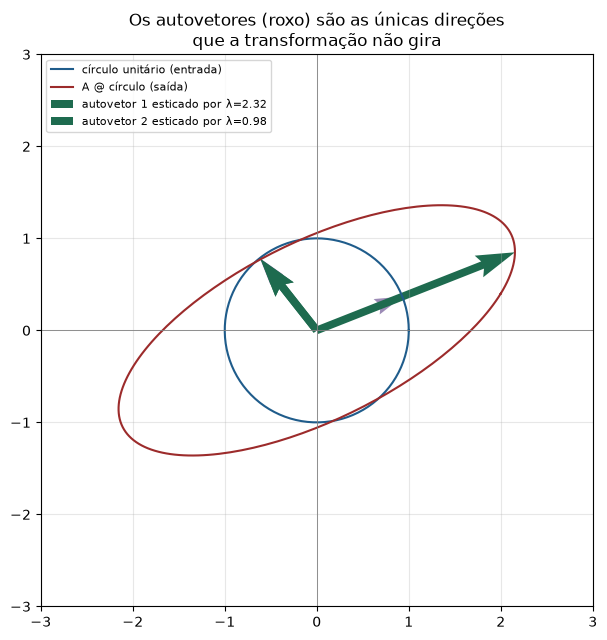

In [3]:
theta = np.linspace(0, 2 * np.pi, 200)
circulo = np.stack([np.cos(theta), np.sin(theta)])
elipse = A @ circulo

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(*circulo, color=AZUL, lw=1.5, label="círculo unitário (entrada)")
ax.plot(*elipse, color=VERMELHO, lw=1.5, label="A @ círculo (saída)")

for i in range(2):
    v = autovetores[:, i]
    lam = autovalores[i].real
    ax.quiver(0, 0, *v, color=ROXO, angles="xy", scale_units="xy", scale=1,
              width=0.01, alpha=0.6)
    ax.quiver(0, 0, *(lam * v), color=VERDE, angles="xy", scale_units="xy",
              scale=1, width=0.014,
              label=f"autovetor {i + 1} esticado por λ={lam:.2f}" if i == 0 else None)
    if i == 1:
        ax.quiver(0, 0, *(lam * v), color=VERDE, angles="xy", scale_units="xy",
                  scale=1, width=0.014, label=f"autovetor {i + 1} esticado por λ={lam:.2f}")

ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_title("Os autovetores (roxo) são as únicas direções\nque a transformação não gira")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

Repare: **toda outra direção** do círculo gira ao virar elipse. Só as duas
direções roxas (os autovetores) mantêm a mesma orientação — apenas mudam de
tamanho, pelo fator $\lambda$.

## 3. Matriz simétrica: o caso especial que sempre se comporta bem

Quando $A$ é simétrica, o teorema espectral garante autovalores reais e
autovetores ortogonais entre si. Vamos comparar `eig` (genérico) com `eigh`
(especializado em simétricas).

In [4]:
# construímos uma matriz simétrica positiva definida a partir de dados reais:
# a covariância É simétrica por construção.
X = rng.multivariate_normal(mean=[0, 0], cov=[[4.0, 2.4], [2.4, 2.0]], size=2000)
C = np.cov(X, rowvar=False)
print("matriz de covariância:\n", C)
print("é simétrica?", np.allclose(C, C.T))

autoval_eig, autovec_eig = np.linalg.eig(C)
autoval_eigh, autovec_eigh = np.linalg.eigh(C)  # eigh já devolve em ordem CRESCENTE

print(f"\neig  : autovalores = {autoval_eig}")
print(f"eigh : autovalores = {autoval_eigh}   (mesmos valores, ordem garantida)")
print(f"\nautovetores de eigh são ortogonais? "
      f"{np.allclose(autovec_eigh.T @ autovec_eigh, np.eye(2))}")

matriz de covariância:
 [[3.9246 2.2935]
 [2.2935 1.889 ]]
é simétrica? True

eig  : autovalores = [5.416 +0.j 0.3976+0.j]
eigh : autovalores = [0.3976 5.416 ]   (mesmos valores, ordem garantida)

autovetores de eigh são ortogonais? True


## 4. O teorema espectral na prática: reconstruindo A a partir de Q e Λ

$A = Q \Lambda Q^\top$. Vamos reconstruir a matriz de covariância só a partir
dos autovalores e autovetores, para provar que nenhuma informação se perdeu.

In [5]:
# eigh ordena crescente; para a leitura de "componente principal" convém
# decrescente — então invertemos.
ordem = np.argsort(autoval_eigh)[::-1]
Lambda = np.diag(autoval_eigh[ordem])
Q = autovec_eigh[:, ordem]

C_reconstruida = Q @ Lambda @ Q.T
print("C original:\n", C)
print("\nC reconstruída (Q @ Lambda @ Q.T):\n", C_reconstruida)
print("\ndiferença máxima:", np.abs(C - C_reconstruida).max())

print(f"\ntraço(C)           = {np.trace(C):.4f}")
print(f"soma dos autovalores = {autoval_eigh.sum():.4f}   <- idênticos")
print(f"det(C)             = {np.linalg.det(C):.4f}")
print(f"produto dos autovalores = {np.prod(autoval_eigh):.4f}   <- idênticos")

C original:
 [[3.9246 2.2935]
 [2.2935 1.889 ]]

C reconstruída (Q @ Lambda @ Q.T):
 [[3.9246 2.2935]
 [2.2935 1.889 ]]

diferença máxima: 8.881784197001252e-16

traço(C)           = 5.8136
soma dos autovalores = 5.8136   <- idênticos
det(C)             = 2.1536
produto dos autovalores = 2.1536   <- idênticos


## 5. A elipse de covariância e os eixos principais

A nuvem de pontos gerada acima tem uma forma alongada porque as duas
variáveis são correlacionadas. Os autovetores da covariância apontam
exatamente ao longo dessa forma — essa é a intuição geométrica que o próximo
notebook generaliza para muitas dimensões (PCA).

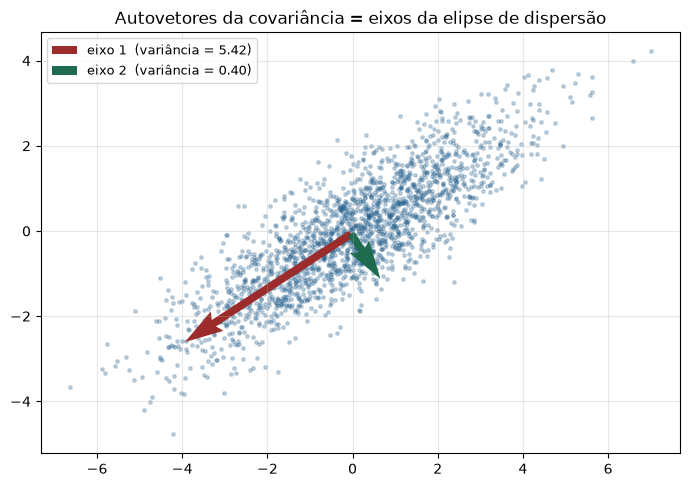

In [6]:
media = X.mean(axis=0)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], s=6, alpha=0.25, color=AZUL)

for i in range(2):
    v = Q[:, i]
    lam = Lambda[i, i]
    # multiplicamos por 2*sqrt(lambda) só para o vetor ficar visível na escala do gráfico
    escala = 2 * np.sqrt(lam)
    ax.quiver(*media, *(escala * v), color=VERMELHO if i == 0 else VERDE,
              angles="xy", scale_units="xy", scale=1, width=0.012,
              label=f"eixo {i + 1}  (variância = {lam:.2f})")

ax.set_aspect("equal")
ax.set_title("Autovetores da covariância = eixos da elipse de dispersão")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Power iteration: como se calcula o maior autovalor sem álgebra simbólica

Multiplicar repetidamente por $A$ e normalizar isola a direção do maior
autovalor absoluto. É simples, é a base de muitos algoritmos de larga escala
(incluindo o PageRank), e vale ver funcionando.

maior autovalor (eigh)          : 5.415966
maior autovalor (power iteration): 5.415966

autovetor (eigh)           : [-0.8383 -0.5452]
autovetor (power iteration): [0.8383 0.5452]


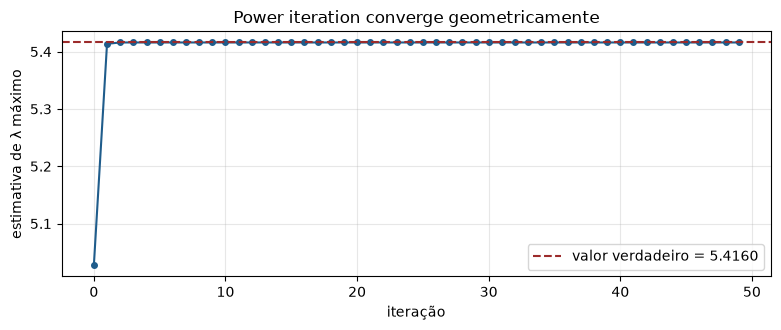

In [7]:
def power_iteration(A, n_iter=50):
    n = A.shape[0]
    v = rng.normal(size=n)
    v /= np.linalg.norm(v)
    historico = []
    for _ in range(n_iter):
        v_novo = A @ v
        lam = np.linalg.norm(v_novo)
        v_novo /= lam
        # o sinal pode oscilar; alinhamos para medir convergência de forma limpa
        if np.dot(v_novo, v) < 0:
            v_novo = -v_novo
        historico.append(lam)
        v = v_novo
    return lam, v, historico


lam_estimado, v_estimado, historico = power_iteration(C)
lam_real = autoval_eigh[ordem][0]
v_real = Q[:, 0]

print(f"maior autovalor (eigh)          : {lam_real:.6f}")
print(f"maior autovalor (power iteration): {lam_estimado:.6f}")
print(f"\nautovetor (eigh)           : {v_real}")
print(f"autovetor (power iteration): {v_estimado}")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(historico, "o-", color=AZUL, ms=4)
ax.axhline(lam_real, color=VERMELHO, ls="--", label=f"valor verdadeiro = {lam_real:.4f}")
ax.set_xlabel("iteração"); ax.set_ylabel("estimativa de λ máximo")
ax.set_title("Power iteration converge geometricamente")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Velocidade de convergência depende do quanto os autovalores estão separados

A teoria prevê: o erro cai proporcionalmente a $(\lambda_2/\lambda_1)^k$.
Quando os dois maiores autovalores estão próximos, a convergência é lenta.

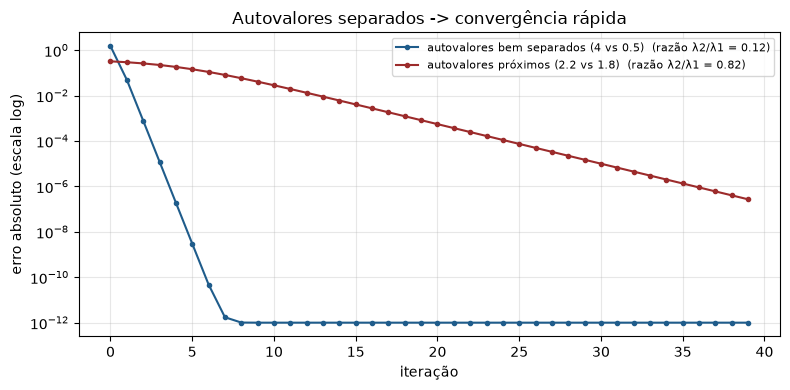

In [8]:
def razao_de_convergencia(cov, n_iter=40):
    autoval = np.sort(np.linalg.eigvalsh(cov))[::-1]
    razao_teorica = abs(autoval[1] / autoval[0])
    _, _, hist = power_iteration(cov, n_iter)
    erro = np.abs(np.array(hist) - autoval[0])
    return razao_teorica, erro


fig, ax = plt.subplots(figsize=(8, 4))
for cov, nome, cor in [
    (np.array([[4.0, 0.0], [0.0, 0.5]]), "autovalores bem separados (4 vs 0.5)", AZUL),
    (np.array([[2.2, 0.0], [0.0, 1.8]]), "autovalores próximos (2.2 vs 1.8)", VERMELHO),
]:
    razao, erro = razao_de_convergencia(cov)
    ax.semilogy(erro + 1e-12, "o-", ms=3, color=cor,
                label=f"{nome}  (razão λ2/λ1 = {razao:.2f})")

ax.set_xlabel("iteração"); ax.set_ylabel("erro absoluto (escala log)")
ax.set_title("Autovalores separados -> convergência rápida")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## O que levar deste notebook

- Autovetores são as direções que uma transformação linear **não gira** — só
  estica pelo fator do autovalor.
- Matrizes simétricas (toda covariância é uma) têm autovalores reais e
  autovetores ortogonais: use sempre `eigh`, nunca `eig`, quando souber que a
  matriz é simétrica.
- $A = Q\Lambda Q^\top$ reconstrói a matriz inteira a partir do espectro —
  nenhuma informação se perde.
- Os autovetores da covariância apontam ao longo da forma da nuvem de pontos:
  essa é a semente geométrica do PCA, no notebook 3.
- Power iteration mostra, de forma construtiva, como o maior autovalor emerge
  de multiplicações repetidas — e por que a convergência depende da separação
  entre os dois maiores autovalores.

→ Próximo: **SVD e posto baixo**, a generalização para matrizes retangulares.